# Loading & Reconstructing Rasters

Reconstructing rasters means taking a gridded dataset (like a seafloor age grid or paleo-topography map) and using a plate tectonic model to shift it back in time—essentially “undoing” millions of years of plate motion to show how that data looked in the past. This notebook walks you through reconstructing rasters through time!

### Setup

Let's begin by importing the required packages:

In [1]:
# Ensure you have the required packages installed:
# Run `pip install gplately cartopy matplotlib numpy plate-model-manager` if you haven't already.
import cartopy.crs as ccrs
import gplately
import matplotlib.pyplot as plt
import xarray as xr
from plate_model_manager import PlateModelManager

2025-10-01 01:22:02 - gplately - ERROR - Failed to import PyGMT. PyGMT requires Python>=3.11.
2025-10-01 01:22:15 - gplately - ERROR - Failed to import PyGMT. PyGMT requires Python>=3.11.


### Loading the Raster

We start by initializing a PlateModelManager and loading the [Muller et al. (2019)]("https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2018TC005462) plate model. Using this model, we create a `PlateReconstruction` object to reconstruct plate boundaries at different times. We then extract layers for coastlines, continental polygons, and continents-ocean boundaries (COBs), and pass them to `PlotTopologies` to prepare for plotting.

Finally, we open an ETOPO raster dataset for present-day topography using `xarray`, extract the elevation (z) and coordinate arrays (lon, lat), and create a `gplately.Raster` object linked to our plate reconstruction for visualization. This dataset is part of the [ETOPO 2022 global relief model](https://www.ncei.noaa.gov/products/etopo-global-relief-model), which provides gridded elevation and bathymetry data at 1 arc-minute (~1.8 km) resolution. The file contains bedrock elevation values (topography for land and bathymetry for ocean) in a regular latitude-longitude grid.

> `NOTE:` The 'Unrecognized zip data!' warning message was printed by the plate-model-manager. It is harmless and can be ignored!

In [ ]:
pm_manager = PlateModelManager()

# Load the Muller 2019 plate model 
muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")

# This object will allow us to reconstruct the plate boundaries at different times
model = gplately.PlateReconstruction(
    muller2019_model.get_rotation_model(),
    muller2019_model.get_topologies(),
    muller2019_model.get_static_polygons()
)

# Coastlines, Continental polygons and COBs
coastlines = muller2019_model.get_layer('Coastlines')
continents = muller2019_model.get_layer('ContinentalPolygons')
COBs = muller2019_model.get_layer('COBs')

# Create PlotTopologies object
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

ds = xr.open_dataset("../../data/ETOPO_2022_v1_60s_N90W180_bed.nc")
data = ds['z'].values  # replace 'z' with the actual variable name
lon = ds['lon'].values
lat = ds['lat'].values

etopo_raster = gplately.Raster(
    data=data,
    extent=[lon.min(), lon.max(), lat.min(), lat.max()],
    plate_reconstruction=model
)

# Set reconstruction time
reconstruction_time = 100  # Ma

c:\Users\nilaf\AppData\Local\Programs\Python\Python311\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'gmt.dll'.
Could not find module 'gmt.dll' (or one of its dependencies). Try using the full path with constructor syntax.
Error loading GMT shared library at 'gmt_w64.dll'.
Could not find module 'gmt_w64.dll' (or one of its dependencies). Try using the full path with constructor syntax.
Error loading GMT shared library at 'gmt_w32.dll'.
Could not find module 'gmt_w32.dll' (or one of its dependencies). Try using the full path with constructor syntax.


### Reconstructing & Plotting

The `etopo_raster` can be reconstructed to past geological times by assigning a plate_reconstruction object (here, the `model` we defined earlier). While a Raster can also accept a plate_reconstruction at initialization, we assign it here explicitly.

We then set the reconstruction time (`gplot.time = 100 Ma`) and visualize the raster at this age using `etopo_raster.imshow()`. Coastlines are overlaid using `gplot.plot_coastlines()` to provide context for the reconstructed topography.

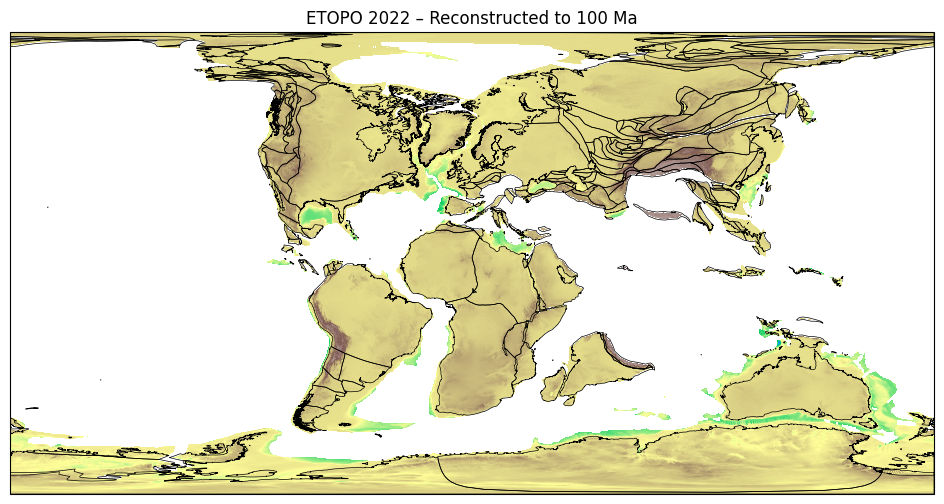

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

reconstructed_raster = etopo_raster.reconstruct(
   time=reconstruction_time,
   partitioning_features=PlateModelManager()
   .get_model("Muller2019")
   .get_layer("ContinentalPolygons"),
)

# Reconstruct raster to the same time
reconstructed_raster.imshow(
    ax, 
    cmap='terrain'
)

# Overlay coastlines at the same time
gplot.time = reconstruction_time
gplot.plot_coastlines(ax, color='black', linewidth=0.5)

plt.title(f"ETOPO 2022 – Reconstructed to {reconstruction_time} Ma")
plt.show()